In [ ]:
import pandas as pd
import seaborn as sns

In [20]:
raw_data =pd.read_csv("HousePricePrediction.csv")
raw_data["SalePrice"]=raw_data["SalePrice"].fillna(raw_data["SalePrice"].mean())
raw_data.sample(8)


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
275,275,50,RL,7264,Inside,1Fam,7,1925,2007,Wd Sdng,0.0,952.0,205000.00000
775,775,120,RM,4500,FR2,TwnhsE,5,1998,1998,VinylSd,0.0,1204.0,162000.00000
314,314,70,RM,9600,Inside,1Fam,7,1925,1990,Wd Sdng,0.0,728.0,178000.00000
1692,1692,80,RL,9734,Inside,1Fam,5,2004,2004,VinylSd,113.0,384.0,180921.19589
2015,2015,60,RL,8450,Inside,1Fam,5,2001,2001,VinylSd,0.0,827.0,180921.19589
472,472,180,RM,3675,Inside,TwnhsE,5,2005,2005,VinylSd,0.0,547.0,148000.00000
1514,1514,50,RL,9724,Inside,1Fam,7,1952,2002,MetalSd,0.0,1140.0,180921.19589
2831,2831,20,RL,13377,Corner,1Fam,5,2006,2006,VinylSd,0.0,1836.0,180921.19589


<Axes: xlabel='MSSubClass', ylabel='SalePrice'>

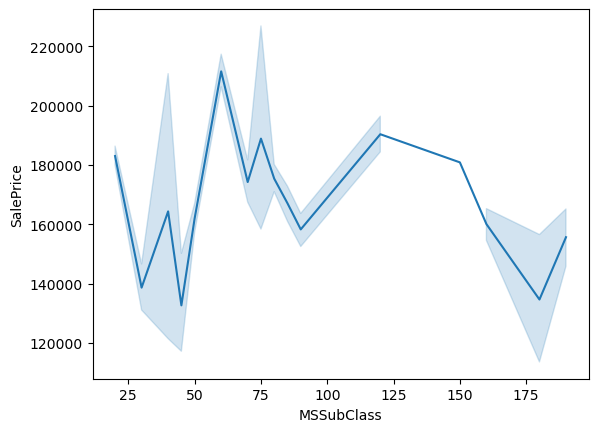

In [23]:
sns.lineplot(data=raw_data,x="MSSubClass",y="SalePrice")

In [14]:
# raw_data.drop(columns=["Id"],inplace=True)
raw_data=raw_data.dropna()
x = raw_data.drop(columns=["SalePrice"])
y=raw_data["SalePrice"]

x["overall_built"] = x["OverallCond"]*x["YearBuilt"]
x = pd.get_dummies(x,columns=["MSZoning","LotConfig","BldgType","Exterior1st"],drop_first=True,dtype=int)

# train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.2,random_state=42)
# model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
# test 
y_pred=model.predict(x_test)
# r2_score 
# evaluation
from sklearn.metrics import r2_score
r2 = r2_score(y_pred,y_test)
print(r2)

0.41079440793336597


In [ ]:
# sns.scatterplot(data=raw_data,x="YearBuilt",y="SalePrice",hue="BldgType")